# Resource Net — Análisis y Exportación de Logs

Este módulo convierte los logs del *Resource Net* (RNLOG) del kernel FreeBSD en archivos CSV listos para análisis y gráficos.

## 📁 Estructura esperada

```
benchmarks/analysis/resource_net/
├── data/            # .log de entrada (uno por configuración de cores)
├── exports/         # CSVs generados (salida)
└── resource_net_analisis.ipynb
```

## 🧩 Formato de entrada (línea por evento)

Ejemplo de línea cruda (syslog):

```
Oct 28 13:14:59 Augusto kernel: 1,100165,kernel,sched_switch,11
```

El *payload* útil es la parte después de `kernel:` y tiene el siguiente esquema:

```
CPU,TID,PROC,FROM,TRANS_ID[,SEQ][,SESSION]
```

- **CPU**: CPU lógico (PCPU).
- **TID**: Thread ID.
- **PROC**: `p_comm` del proceso (p.ej. `loadpulse`, `kernel`, `sshd`).
- **FROM**: etiqueta del sitio de llamada (p.ej. `resource_fire_single_transition`, `sched_switch`, `sched_add`, `sched_choose`, etc.).
- **TRANS_ID**: índice entero de la transición en la *resource net*.
- **SEQ** *(opcional)*: contador por CPU (si se compila con `RNLOG_WITH_SEQ`).
- **SESSION** *(opcional)*: ID de sesión (si se compila con `RNLOG_WITH_SESSION`).

> Las líneas sin al menos las 5 columnas base se descartan.


```



---


In [20]:
from pathlib import Path
import csv
import re

# Rutas (relativas al notebook)
DATA_DIR = Path("data")
OUT_DIR = Path("exports")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Regex: elimina todo hasta y incluyendo "kernel:" (con cualquier fecha/hora/hostname antes)
KERNEL_PREFIX_RE = re.compile(r".*?\bkernel:\s*")

# Columnas estándar y opcionales
BASE_COLS = ["CPU", "TID", "PROC", "FROM", "TRANS_ID"]
OPT_COLS  = ["SEQ", "SESSION"]

def parse_line(line: str):
    """
    Devuelve dict con columnas o None si la línea no es parseable.
    """
    line = line.strip()
    if not line:
        return None
    # Quitar prefijo syslog
    payload = KERNEL_PREFIX_RE.sub("", line)
    # Si no hubo "kernel:", quizás ya sea puro payload
    if payload == line and ":" in line:
        # Línea con otros prefijos desconocidos
        # Como fallback: tomar lo que esté después del último ':'
        payload = line.split(":")[-1].strip()

    parts = [p.strip() for p in payload.split(",")]
    if len(parts) < 5:
        return None  # no alcanza para las columnas base

    row = {
        "CPU": parts[0],
        "TID": parts[1],
        "PROC": parts[2],
        "FROM": parts[3],
        "TRANS_ID": parts[4],
    }
    # Manejo de opcionales
    if len(parts) >= 6:
        row["SEQ"] = parts[5]
    if len(parts) >= 7:
        row["SESSION"] = parts[6]
    return row

def write_csv(rows, out_path, have_seq, have_session):
    cols = BASE_COLS + (["SEQ"] if have_seq else []) + (["SESSION"] if have_session else [])
    with out_path.open("w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=cols)
        w.writeheader()
        for r in rows:
            # completar faltantes si hiciera falta
            for c in cols:
                r.setdefault(c, "")
            w.writerow(r)

def process_log(log_path: Path):
    rows = []
    have_seq = False
    have_session = False

    with log_path.open("r", errors="ignore") as f:
        for line in f:
            r = parse_line(line)
            if not r:
                continue
            have_seq = have_seq or ("SEQ" in r)
            have_session = have_session or ("SESSION" in r)
            rows.append(r)

    out_path = OUT_DIR / (log_path.stem + ".csv")
    write_csv(rows, out_path, have_seq, have_session)
    return out_path, len(rows), have_seq, have_session

# Procesar todos los .log en data/
log_files = sorted(DATA_DIR.glob("*.log"))
if not log_files:
    print("No se encontraron .log en", DATA_DIR.resolve())

summary = []
for lf in log_files:
    out_path, n, has_seq, has_sess = process_log(lf)
    summary.append((lf.name, out_path.name, n, has_seq, has_sess))
    print(f"✔ {lf.name} → exports/{out_path.name} | filas: {n} | SEQ: {has_seq} | SESSION: {has_sess}")

# (Opcional) Mostrar un pequeño resumen ordenado
if summary:
    maxn = max(n for _,_,n,_,_ in summary)
    print("\nResumen:")
    for name, outname, n, has_seq, has_sess in sorted(summary, key=lambda x: x[2], reverse=True):
        print(f" - {name} → {outname} | filas={n} | SEQ={has_seq} | SESSION={has_sess}")


✔ resource_net_2CORE.log → exports/resource_net_2CORE.csv | filas: 193123 | SEQ: True | SESSION: True
✔ resource_net_3CORE.log → exports/resource_net_3CORE.csv | filas: 619257 | SEQ: True | SESSION: True
✔ resource_net_4CORE.log → exports/resource_net_4CORE.csv | filas: 420545 | SEQ: True | SESSION: True
✔ resource_net_5CORE.log → exports/resource_net_5CORE.csv | filas: 588320 | SEQ: True | SESSION: True

Resumen:
 - resource_net_3CORE.log → resource_net_3CORE.csv | filas=619257 | SEQ=True | SESSION=True
 - resource_net_5CORE.log → resource_net_5CORE.csv | filas=588320 | SEQ=True | SESSION=True
 - resource_net_4CORE.log → resource_net_4CORE.csv | filas=420545 | SEQ=True | SESSION=True
 - resource_net_2CORE.log → resource_net_2CORE.csv | filas=193123 | SEQ=True | SESSION=True


# Resource Net — Uso de Cores (% no–idle) y Gráficos de Barras

Este documento describe cómo calcular, para **cada CSV** exportado desde RNLOG, el **porcentaje de uso por core** y generar **gráficos de barras**.

## 🧠 Definición (proxy de uso)
Como los CSV no incluyen timestamps de ejecución, se usa un proxy:
**Uso(core) ≈ (eventos con `PROC` ≠ `idle`) / (eventos totales del core)** × 100.
Si un CSV no tiene columna `PROC`, se cae a: **Proporción de eventos por core** (informativa pero no equivalente a uso).

✔ Guardado: exports/resource_net_2CORE_events_per_cpu.csv


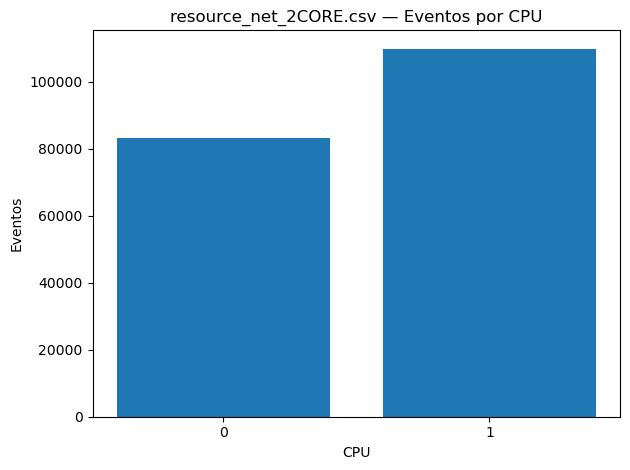

✔ Gráfico: exports/resource_net_2CORE_events_per_cpu.png
✔ Guardado: exports/resource_net_3CORE_events_per_cpu.csv


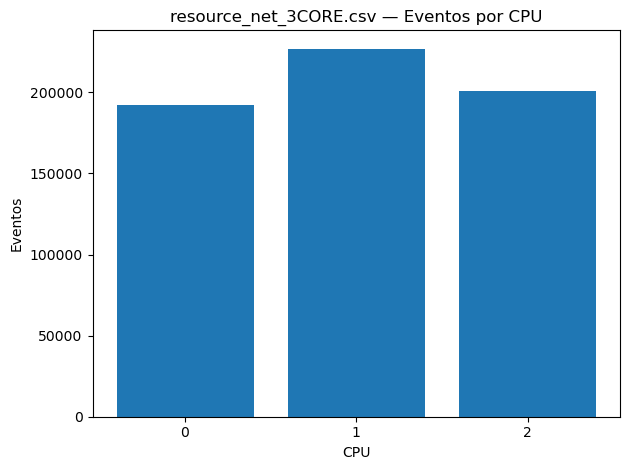

✔ Gráfico: exports/resource_net_3CORE_events_per_cpu.png
✔ Guardado: exports/resource_net_4CORE_events_per_cpu.csv


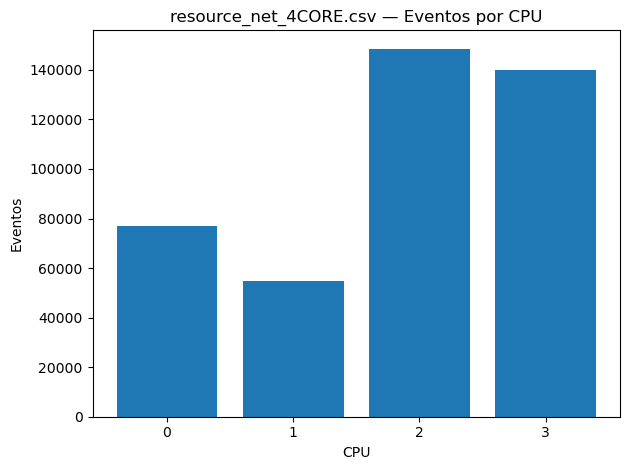

✔ Gráfico: exports/resource_net_4CORE_events_per_cpu.png
✔ Guardado: exports/resource_net_5CORE_events_per_cpu.csv


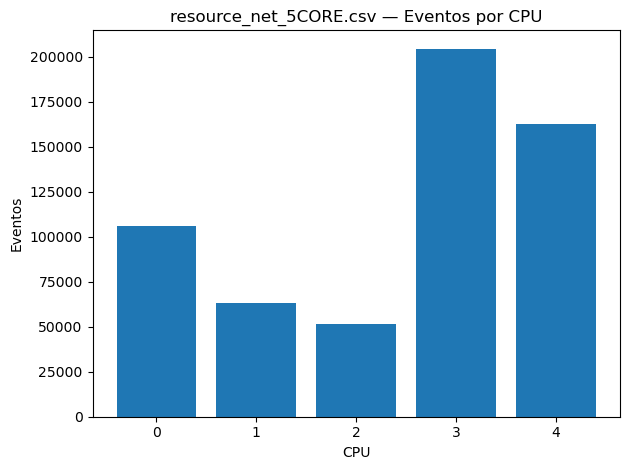

✔ Gráfico: exports/resource_net_5CORE_events_per_cpu.png

📄 Resumen consolidado: exports/events_per_cpu_summary.csv


In [21]:
# === Conteo de filas por CPU (sin pandas) + barras por CSV ===
from pathlib import Path
import csv

EXPORTS_DIR = Path("exports")
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

csv_files = sorted(EXPORTS_DIR.glob("*.csv"))
if not csv_files:
    raise SystemExit("No hay CSVs en exports/.")

def load_header_index(p):
    with p.open("r", newline="", encoding="utf-8", errors="ignore") as f:
        rd = csv.reader(f)
        header = next(rd, None)
        if not header:
            return None, []
        idx = {h.strip(): i for i, h in enumerate(header)}
        rows = [r for r in rd if r]
    return idx, rows

def count_by_cpu(idx, rows):
    if "CPU" not in idx:
        raise ValueError("Falta columna 'CPU'.")
    counts = {}
    for r in rows:
        i = idx["CPU"]
        cpu = (r[i].strip() if i < len(r) else "")
        if cpu == "":
            continue
        counts[cpu] = counts.get(cpu, 0) + 1
    # ordenar CPUs numéricamente si se puede
    def keyfn(x):
        return (x.isdigit(), int(x) if x.isdigit() else x)
    return dict(sorted(counts.items(), key=lambda kv: keyfn(kv[0])))

# backend de gráficos
use_matplotlib = False
use_plotly = False
try:
    import matplotlib.pyplot as plt
    use_matplotlib = True
except Exception:
    try:
        import plotly.express as px
        use_plotly = True
    except Exception:
        pass

summary = []  # filas: file, CPU, events_total

for csv_path in csv_files:
    try:
        idx, rows = load_header_index(csv_path)
        if idx is None:
            print(f"⚠ {csv_path.name}: vacío")
            continue
        per_cpu = count_by_cpu(idx, rows)
    except Exception as e:
        print(f"⚠ {csv_path.name}: {e}")
        continue

    # guardar csv por archivo
    out_counts = EXPORTS_DIR / f"{csv_path.stem}_events_per_cpu.csv"
    with out_counts.open("w", newline="", encoding="utf-8") as f:
        wr = csv.writer(f)
        wr.writerow(["CPU", "events_total"])
        for cpu, n in per_cpu.items():
            wr.writerow([cpu, n])
            summary.append([csv_path.name, cpu, n])
    print(f"✔ Guardado: {out_counts}")

    # gráfico por archivo
    xs = [str(c) for c in per_cpu.keys()]
    ys = list(per_cpu.values())
    title = f"{csv_path.name} — Eventos por CPU"

    if use_matplotlib:
        plt.figure()
        plt.bar(xs, ys)
        plt.title(title)
        plt.xlabel("CPU")
        plt.ylabel("Eventos")
        plt.tight_layout()
        out_png = EXPORTS_DIR / f"{csv_path.stem}_events_per_cpu.png"
        plt.savefig(out_png, dpi=150)
        plt.show()
        print(f"✔ Gráfico: {out_png}")
    elif use_plotly:
        fig = px.bar(x=xs, y=ys, labels={"x":"CPU","y":"Eventos"}, title=title)
        out_html = EXPORTS_DIR / f"{csv_path.stem}_events_per_cpu.html"
        fig.write_html(str(out_html), include_plotlyjs="cdn")
        fig.show()
        print(f"✔ Gráfico: {out_html}")
    else:
        print("ℹ No hay backend de gráficos disponible (matplotlib/plotly).")

# resumen consolidado
summary_csv = EXPORTS_DIR / "events_per_cpu_summary.csv"
with summary_csv.open("w", newline="", encoding="utf-8") as f:
    wr = csv.writer(f)
    wr.writerow(["file", "CPU", "events_total"])
    wr.writerows(summary)
print(f"\n📄 Resumen consolidado: {summary_csv}")


In [22]:
#!/usr/bin/env python3
# Genera UN solo CSV por archivo base en exports/: matriz TID x CPU (solo PROC=loadpulse)
from pathlib import Path
import csv

EXPORTS_DIR = Path("exports")
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

def is_base_csv(p: Path) -> bool:
    """Evitar CSVs derivados: solo procesar los base exportados del log."""
    name = p.name
    skip_suffixes = (
        "_events_per_cpu.csv",
        "_core_usage.csv",
        "_loadpulse_tid_cpu_counts.csv",
        "_loadpulse_events_per_cpu.csv",
        "_events_per_cpu.png",
        "_events_per_cpu.html",
        "_core_usage.png",
        "_events_per_cpu.csv",
        "_loadpulse_tid_by_cpu.csv",
    )
    return name.endswith(".csv") and not any(name.endswith(s) for s in skip_suffixes)

def load_header_index(p: Path):
    with p.open("r", newline="", encoding="utf-8", errors="ignore") as f:
        rd = csv.reader(f)
        header = next(rd, None)
        if not header:
            return None, []
        cols = [h.strip() for h in header]
        idx = {c: i for i, c in enumerate(cols)}
        rows = [r for r in rd if r]
    return idx, rows

def sorted_numeric(values):
    """Orden numérico cuando se puede, alfabético si no."""
    def keyfn(s):
        s = str(s)
        return (s.isdigit(), int(s) if s.isdigit() else s)
    return sorted({str(v) for v in values}, key=keyfn)

def build_tid_cpu_matrix(idx, rows):
    """Devuelve (cpus, tids, counts) con counts[(tid,cpu)] = int, solo PROC=loadpulse."""
    for need in ("CPU","TID","PROC"):
        if need not in idx:
            raise ValueError(f"Falta columna requerida: {need}")

    counts = {}
    tids, cpus = set(), set()

    for r in rows:
        cpu  = (r[idx["CPU"]].strip()  if idx["CPU"]  < len(r) else "")
        tid  = (r[idx["TID"]].strip()  if idx["TID"]  < len(r) else "")
        proc = (r[idx["PROC"]].strip() if idx["PROC"] < len(r) else "")
        if not cpu or not tid or proc != "loadpulse":
            continue
        counts[(tid, cpu)] = counts.get((tid, cpu), 0) + 1
        tids.add(tid); cpus.add(cpu)

    cpus = sorted_numeric(cpus)
    tids = sorted_numeric(tids)
    return cpus, tids, counts

def write_matrix_csv(out_path: Path, cpus, tids, counts):
    with out_path.open("w", newline="", encoding="utf-8") as f:
        wr = csv.writer(f)
        wr.writerow(["TID"] + cpus)
        for tid in tids:
            wr.writerow([tid] + [counts.get((tid, cpu), 0) for cpu in cpus])

def main():
    base_csvs = [p for p in sorted(EXPORTS_DIR.glob("*.csv")) if is_base_csv(p)]
    if not base_csvs:
        raise SystemExit("No hay CSVs base en 'exports/'.")

    for csv_path in base_csvs:
        try:
            idx, rows = load_header_index(csv_path)
            if idx is None:
                print(f"⚠ {csv_path.name}: vacío; omito.")
                continue
            cpus, tids, counts = build_tid_cpu_matrix(idx, rows)
        except Exception as e:
            print(f"⚠ {csv_path.name}: {e}")
            continue

        out_path = EXPORTS_DIR / f"{csv_path.stem}_loadpulse_tid_by_cpu.csv"
        write_matrix_csv(out_path, cpus, tids, counts)

        print(f"✔ {csv_path.name}: {len(tids)} TIDs de loadpulse, {len(cpus)} CPUs → {out_path}")

if __name__ == "__main__":
    main()


⚠ events_per_cpu_summary.csv: Falta columna requerida: TID
✔ resource_net_2CORE.csv: 8 TIDs de loadpulse, 2 CPUs → exports/resource_net_2CORE_loadpulse_tid_by_cpu.csv
✔ resource_net_3CORE.csv: 8 TIDs de loadpulse, 3 CPUs → exports/resource_net_3CORE_loadpulse_tid_by_cpu.csv
✔ resource_net_4CORE.csv: 8 TIDs de loadpulse, 4 CPUs → exports/resource_net_4CORE_loadpulse_tid_by_cpu.csv
✔ resource_net_5CORE.csv: 8 TIDs de loadpulse, 5 CPUs → exports/resource_net_5CORE_loadpulse_tid_by_cpu.csv
